#  Impact of AOCS jitter on the photometry at camera level

$\textbf{Goals}$

Test the impact and behavior of spacecraft Attitude and Orbital Control System (AOCS) jitter on camera level. 

$\textbf{Context}$

In order to achieve the required noise budget at mission level, the PMC has defined Mean Pointing Error and Relative Pointing Error requirements at camera level. In the high frequency range ($f \gg 0.04$Hz), the dominant contribution results from the performance of the attitude and orbit control system of the S/C (jitter).

$\textbf{Simulations}$

To test the impact of jitter it should be enough to have several short-term simulations (1 day long), for 24 N-CAMs and several quarters. Specifically one simulation with fast jitter (8 Hz), and one simulation without jitter (only white noise jitter) shall be compared to tell whether a jitter correction on-ground is mandatory or not. 
Prime have delivered a high frequency jitter simulations for one N-Cam w.r.t. to F2-Cam with a cadence of 8 Hz and duration of 27h. We shall investigate if this simulation can be cycled to the remaining cameras and how this might impact the forthcoming analysis.

As a baseline, we keep on-ground processing as an option for WC of the impact of jitter.

$\textbf{Data analysis}$

### Setup notebook

In [428]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [429]:
import os
import h5py
import glob
import numpy as np
import pandas as pd
from zipfile import ZipFile
import matplotlib.pyplot as plt

# Handle warnings
# import warnings
# warnings.filterwarnings('ignore')

# PlatoSim
import platosim.plot as pt
import platosim.utilities as ut
import platosim.referenceFrames as rf
from platosim.photometryfile import PhotometryFile
from platosim.matplotlibrc   import setup
setup()

### Functions

In [430]:
def matrixMisalignment(x, y, z):   
    r11 = + np.cos(x)*np.cos(z) - np.sin(x)*np.sin(z)*np.sin(y)
    r12 = - np.cos(x)*np.sin(z) - np.sin(x)*np.cos(z)*np.cos(y)
    r13 = + np.sin(x)*np.sin(z)
    r21 = + np.sin(x)*np.cos(z) + np.cos(x)*np.sin(z)*np.cos(y)
    r22 = - np.sin(x)*np.sin(z) - np.cos(x)*np.cos(z)*np.cos(y)
    r23 = - np.cos(x)*np.sin(z)
    r31 = + np.sin(z)*np.sin(y)
    r32 = + np.cos(z)*np.sin(y)
    r33 = - np.cos(y)   
    R = np.array([[r11, r12, r13],
                  [r21, r22, r23],
                  [r31, r32, r33]])
    return R


def changeOfPointing(x, y, z, phi, theta):
    R = np.array([[ 0, -z,  y],
                  [ z,  0, -x],
                  [-y,  x,  0]])
    A = np.array([[np.cos(phi)*np.sin(theta)],
                  [np.sin(phi)*np.sin(theta)], 
                  [1]])
    return np.dot(R,A).T

### User defined parameters

In [437]:
# Perfect pointing to provisional SPF (ICRS - equatorial)
workdir  = '/lhome/nicholas/software/workdir/kul21/input'
inputdir = '/lhome/nicholas/software/PlatoSim/inputfiles'
aocsdir  = '/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2021sep'
ra  = 86.79870508
dec = -46.39594703
rot = -4.
sigma = 3
quarters = np.arange(1,9) # Q1-Q8

---

## 1) Pointing errors 

### 1.1) Prime CM LOS AOCS + TED

Each LOS variable has a sample rate of 8Hz and is in radians. The periods where reaction wheel offloading were simulated, including a
tranquilisation time after the transition from OLM back to GAM are set to `NaN`.

In [438]:
# Load Prime 
f = h5py.File(aocsdir + '/CM_LOS_Combined_v2.mat', 'r')
xLOS = f['LOSX'][0]
yLOS = f['LOSY'][0]
zLOS = f['LOSZ'][0]

In [440]:
# Shorten time series and create time points
tdur = 27      # [h]
t    = 0.125   # [s] 8 Hz
l    = int(tdur * 3600 / t)
time = np.arange(0, len(xLOS), t)
signals = [xLOS[:l], yLOS[:l], zLOS[:l]]

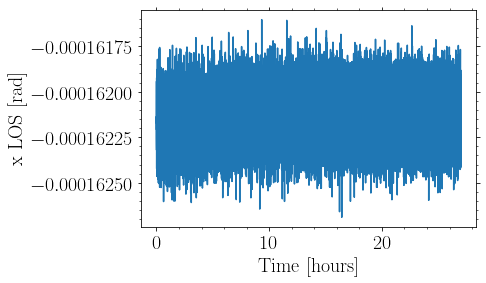

In [441]:
# Plot x LOS for illustration
plt.plot(time[:l]/3600, xLOS[:l], '-')
plt.xlabel('Time [hours]')
plt.ylabel('x LOS [rad]')
plt.show()

### 1.1) AOCS jitter time series from Prime

We use the $8\,\rm Hz$ AOCS jitter time series simulated delivered by the ESA Prime contractor the 2021-01-09. See the technidal note: *Description of pointing data delivery as part of System PDR* (`PTO-OHB-SYS-MEM-0222 i.1.0`). This dataset consist of several simulations of which the first called `PLATO_PDR_FPM_02_longrun_APE`. 

In [25]:
df = pd.read_csv(f'{aocsdir}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])
df.head()

,t,x,y,z
0,1000.000,0.000001,9.850000e-07,2.750000e-07
1,1000.125,0.000001,9.780000e-07,2.940000e-07
2,1000.250,0.000001,9.840000e-07,3.200000e-07
3,1000.375,0.000001,9.960000e-07,3.510000e-07
4,1000.500,0.000001,1.000000e-06,3.770000e-07


In [26]:
# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

,t,x,y,z
0,0.000,0.301147,0.203171,0.056723
1,0.125,0.301147,0.201727,0.060642
2,0.250,0.294959,0.202965,0.066005
3,0.375,0.286708,0.205440,0.072399
4,0.500,0.276395,0.206265,0.077762


In [27]:
# Split time from signals to adapt to plots below
data = df.to_numpy()
time    = data[:,0]
signals = data[:,1:]

In [28]:
# Save jitter file
np.savetxt(f'{workdir}/AOCS_Prime_2020jan_longrun_28h_8Hz.txt', data, delimiter=' ',
          fmt=['%.3f', '%.9f', '%.9f', '%.9f'])

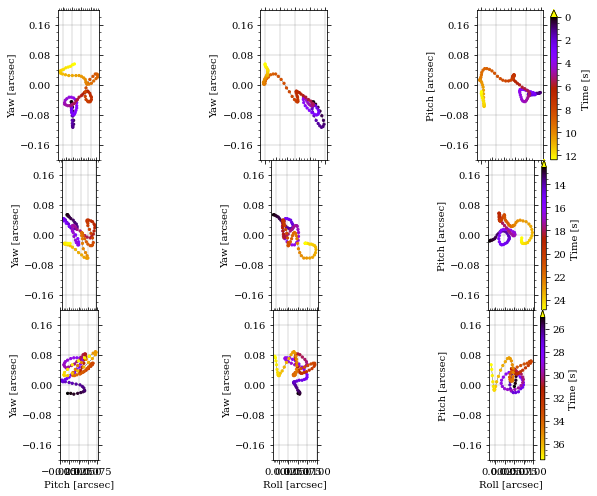

In [29]:
# Plot 
platosim.plot.plotYawPitchRollJitter(time, signals.T, clabel='Time [s]', title='AOCS time series')
plt.show()

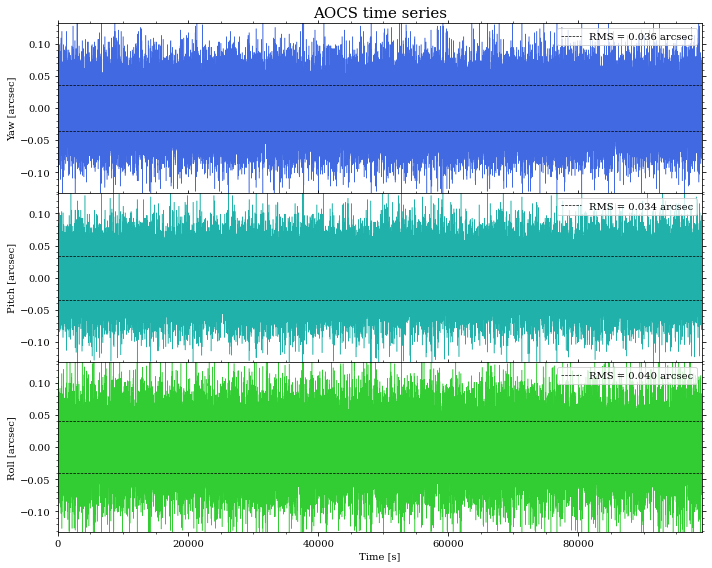

In [30]:
# Plot AOCS time series and the RMS of each component
fig = plt.figure(figsize=(10,8))
platosim.plot.plotYawPitchRollTimeSeries(fig, time, signals.T, ['s', 'arcsec'], 'AOCS time series')
plt.show()

AttributeError: module 'platosim.noise' has no attribute 'powerDensityFFT'

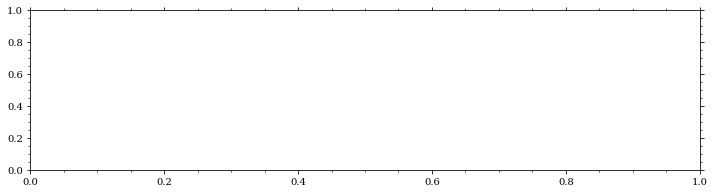

In [31]:
# Plot# Plot the Power Spectral Density (PSD)
fig = plt.figure(figsize=(12,10))
platosim.plot.plotYawPitchRollPSD(fig, time, signals.T, labels=['s', 'arcsec'], title='AOCS time series')
plt.show()

### 1.2) Pointing Reproducibility Error (PRE)

In [ ]:
# Coordinates
ICRS = np.array([ra, dec, rot])

# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 3.0/3600
b = 6.0/3600

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(len(quarters))])
bb = np.array([np.random.normal(0, b/sigma) for i in range(len(quarters))])

# Corresponding yaw, pitch, roll
y = tt
z = 3 * y
x = bb - z

# ICRS pointing angles
phi   = np.deg2rad(ra)
theta = np.deg2rad(dec)

# Find change to pointing for quarters
coor = np.zeros((len(quarters), 4))
for i in range(len(quarters)):
    data = changeOfPointing(x[i], y[i], z[i], phi, theta)[0]
    coor[i,:] = np.append(quarters[i], data)

# Save file with relative pointing errors [deg]
np.savetxt(f'{outdir}/PRE.txt', coor, fmt=['%i', '%0.8f', '%0.8f', '%0.8f'])

# Print generated values
print('Yaw, Pitch, and Roll angles')
print(x)
print(y)
print(z)
print('\nChange of coordinates [arcsec]')
print(coor*3600)
print('\nNew coordinates [deg]')
for i in range(len(quarters)):
    print(coor[i][1]+ra, coor[i][2]+dec, coor[i][3])

### 1.3) Camera alignment errors in yaw, pitch, and roll (x, y, z)

In [ ]:
# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 4.5/60  # [deg]
b = 9.0/60  # [deg]

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(24)])
bb = np.array([np.random.normal(0, b/sigma) for i in range(24)])

# Corresponding yaw, pitch, roll
dy = tt
dz = 3 * dy
dx = bb - dz
mu, sigma = 0, sigma # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)
count, bins, ignored = plt.hist(s, 30, density=True)

# Plot histogram and data
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * 
         np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

# Save APE camera misalignments
np.savetxt('APE.txt', np.transpose([tt, bb]), fmt='%.8f')

# Print generate values
print('Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]')
print(np.transpose([tt, bb, dx, dy, dz])*60)

---

---

## 2) Data Analysis

In [376]:
# Read path
path = '/lhome/nicholas/sims_kul21/jitterNone/000000001/' 

# Fetch all zip files
import glob
files = glob.glob(path+ "*.zip")

# Unpack zip files
from zipfile import ZipFile
with ZipFile(files[0], 'r') as unzip:
    unzip.extractall(path)
    
# Get file names
filename_ftr = files[0][:-3] + "ftr"
filename_cat = files[0][:-3] + "cat"

In [334]:
# Load feather file
lc = PhotometryFile(filename_ftr)

In [335]:
df = lc.data()
df.head()

,index,time,flux,cx,cy,bg,flux_err,cx_err,cy_err,bg_err,chi2,iter,lamb
0,0,7776012.5,568463.431688,2.970300,2.579325,2100.835931,801.292857,0.000995,0.000670,13.601044,186.083792,6,111.111111
1,1,7776037.5,567305.504564,2.969672,2.579021,2531.980149,803.924969,0.000999,0.000673,14.181518,166.269247,6,0.000137
2,2,7776062.5,567277.690471,2.969850,2.581541,2525.746596,803.723039,0.001000,0.000674,14.167387,168.831896,6,111.111111
3,3,7776087.5,567234.017996,2.972145,2.579125,2521.802496,803.581946,0.001001,0.000673,14.161327,169.425822,6,100000.000000
4,4,7776112.5,568844.658326,2.969968,2.580736,2521.369501,804.818065,0.000998,0.000673,14.168352,165.831939,6,111.111111


In [380]:
# Fetch NSR [ppm/sqrt(h)]
lc.getRMS(column="flux_med", unit="ppm")

117.4662799939503

In [382]:
lc.getRMS(column="flux_err", unit="e/s")

0.42236123858661023

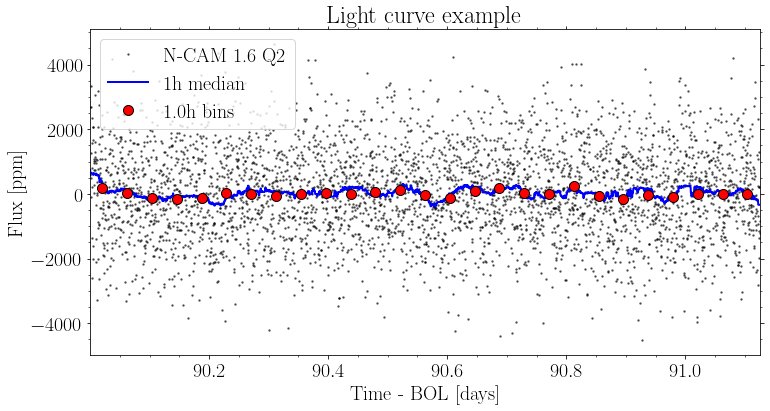

In [402]:
# Create a plot of 
fig, ax = lc.plot(flux_unit="ppm", errorbar=False, median_filter=True, binsize=144)
ax.set_title('Light curve example');

In [370]:
time_bin, flux_bin, tbins = lc.rebin(unit="ppm")
flux_bin

array([ 169.00313461,   27.82672816, -130.4545866 , -142.80446599,
       -112.69792823,   33.20207116,   -2.97230545,  -67.37215294,
         -1.61522338,   40.85838676,    4.45758947,   51.07946211,
        126.51925321,  -48.78819417, -123.05079704,   89.90048037,
        167.63428246,   37.37665336,  -14.06551234,  235.87962479,
        -60.42590898, -164.44182619,  -47.7628951 ,  -84.6492869 ,
          2.41915727,    6.31868502,    2.78272432])

In [371]:
ut.rootMeanSquare(flux_bin)

97.47534748125283

In [208]:
cols = ["id", "ra", "dec", "x", "y", "mag", "ccd", "xccd", "yccd", "xfp", "yfp"]
dc = pd.read_csv(filename_cat, delimiter=' ', comment='#', names=cols)

f = 247.52 # [mm] 
r = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(dc["xfp"][0], dc["yfp"][0], f))

# Custom metric to measure the stellar pollution ratio
M = 0
n = len(dc["mag"])
for i in range(1, n):
    dmag = dc["mag"].diff()[i]  
    rpix = np.sqrt(dc["x"].diff()[i]**2 + dc["y"].diff()[i]**2)
    M += 1/(1+dmag+rpix)
M

0.1580360239361442

In [209]:
dc

,id,ra,dec,x,y,mag,ccd,xccd,yccd,xfp,yfp
0,1,75.485956,-52.449078,3.944553,3.575602,9.64,3,3026.944553,4395.575602,55.783466,-3.360977
1,2,75.488251,-52.455317,5.479605,4.053328,13.36,3,3028.479605,4396.053328,55.811097,-3.352378


In [214]:
xcen = dc["x"][0] - 3.5
ycen = dc["y"][0] - 3.5
rcen = np.sqrt(xcen**2 + ycen**2)
rcen

0.45093576204307584

In [254]:
# Mean flux error in percent
flux     = lc.flux()
flux_err = lc.flux_err()
flux_err_percent = flux_err.mean() / flux.mean() * 100
flux_err_percent

0.14173416775143954

In [255]:
# Mean centroid error in percent
xcen = lc.xcen(unit="pix")
ycen = lc.ycen(unit="pix")
xcen_err = lc.xcen_err(unit="pix")
ycen_err = lc.ycen_err(unit="pix")
rcen     = np.sqrt(xcen**2 + ycen**2)
rcen_err = np.sqrt(xcen_err**2 + ycen_err**2)
rcen_err_percent = rcen_err.mean() / rcen.mean() * 100
rcen_err_percent

0.03064183328247153

In [189]:
phot.time()
phot.flux_err()
xcen =phot.xcen(unit="rel")
phot.xcen_err(unit="pix")
ycen = phot.ycen(unit="rel")
# phot.xcen_err(unit="pix")

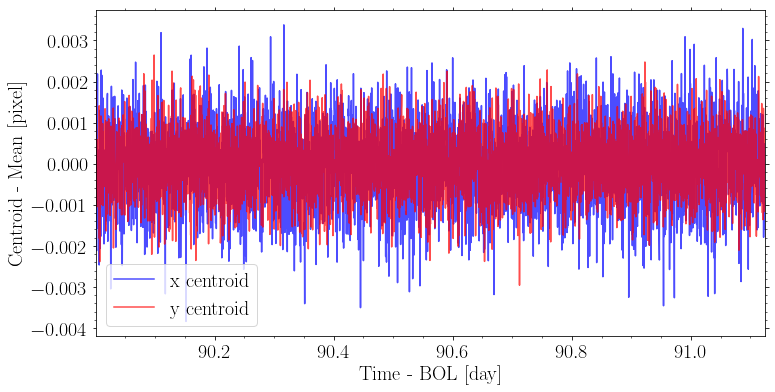

In [15]:
lc.plotCentroid(cen_unit="rel");

In [16]:
lc.getRMS(column="xcen", unit="rel")

0.0007774869028163706

In [17]:
lc.getMAD(column="ycen", unit="rel")

0.0006022984374285536

In [19]:
lc.obs()

(1, 6, 2)

In [312]:
# User parameters
inputDir   = "/lhome/nicholas/sims_kul21/jitterNone"
outputFile = os.getcwd() + "/resultsJitterNone.ftr"
numStar = 400

# Open a pandas data frame and write to it
df = pd.DataFrame()
cols = ["id", "ra", "dec", "x", "y", "mag", "ccd", "xccd", "yccd", "xfp", "yfp"]
f = 247.52 # [mm] 

# Loop over star simulated

for i in range(1, numStar+1):
    
    # Print star processed
    print(i)
    
    # Read path
    starIDfolder = f"{i}".zfill(9)
    path = f"{inputDir}/{starIDfolder}/" 

    # Fetch all zip files
    files = glob.glob(path+ "*.zip")
    numFiles = len(files)
    
    # Loop over each group/cam/quarter simulation
    
    for j in range(numFiles):
    
        # Unpack zip files
        with ZipFile(files[j], "r") as unzip:
            unzip.extractall(path)
    
        # Get file names
        filename_ftr = files[j][:-3] + "ftr"
        filename_cat = files[j][:-3] + "cat"
        filename_inv = files[j][:-3] + "invert"    
        
        # Fetch light curve object
        try: lc = PhotometryFile(filename_ftr)
        except: pass
        else:
        
            # Fetch NSR from RMS [ppm/sqrt(h)]
            NSR_rms = lc.getRMS(column="flux_med", unit="ppm")
                
            # Fetch info about observation
            group, camera, quarter = lc.obs()
        
            # Fetch info about target star
            dc = pd.read_csv(filename_cat, delimiter=' ', comment='#', names=cols)

            # Fetch V magnitude
            mag = dc["mag"][0]
            
            # Distance from optical axis [deg]
            rOA = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(dc["xfp"][0], dc["yfp"][0], f))
                
            # Intra-pixel position
            xcen = dc["x"][0] - 3.5
            ycen = dc["y"][0] - 3.5
            rCP = np.sqrt(xcen**2 + ycen**2)
            
            # Mean centroid error in percent
            xcen     = lc.xcen()
            ycen     = lc.ycen()
            xcen_err = lc.xcen_err()
            ycen_err = lc.ycen_err()
            rcen     = np.sqrt(xcen**2 + ycen**2)
            rcen_err = np.sqrt(xcen_err**2 + ycen_err**2)
            rcen_err_mean = rcen_err.mean() / rcen.mean() * 100
            if rcen_err_mean > 100: rcen_err_mean = 100
            
            # Mean flux error in percent
            flux     = np.abs(lc.flux())
            flux_err = np.abs(lc.flux_err())
            flux_err_mean = flux_err.mean() / flux.mean() * 100                
            if flux_err_mean > 100: flux_err_mean = 100
            
            # Custom metric to measure the stellar pollution ratio
            SPR = 0
            n = len(dc["mag"])
            if n >= 1:
                for i in range(1, n):
                    dmag = dc["mag"].diff()[i]  
                    rpix = np.sqrt(dc["x"].diff()[i]**2 + dc["y"].diff()[i]**2)
                    SPR += 1/(1+dmag+rpix)
                    # If the contaminants is brighter than the target SPR becomes negative.
                    # Here we are only interested in the absolute pollution:
                    if SPR < 0: SPR += 1
        
            # Write data to feather
            data = {"star":i, "group":group, "camera":camera, "quarter":quarter, "mag":mag, "rOA":rOA, "rCP":rCP, 
                    "flux_err_mean":flux_err_mean, "rcen_err_mean":rcen_err_mean, "SPR":SPR, "NSR":NSR_rms}
            df = df.append(data, ignore_index=True)
            
            # Delete unpacked files again to not overflow storage memory
            os.remove(filename_ftr)
            os.remove(filename_cat)
            os.remove(filename_inv)
            
# Save final feather
df = df.astype({"star":int, "group":int, "camera":int, "quarter":int, "rOA":np.float32, "rCP":np.float32, 
                "flux_err_mean":np.float32, "rcen_err_mean":np.float32, "SPR":np.float32, "NSR":np.float32})
df.to_feather(outputFile)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


### 2.1) No jitter

In [403]:
# Load results and sort logically
df = pd.read_feather(outputFile)
# df = df.sort_values(by=["star", "group", "camera", "quarter"])
df

,star,group,camera,quarter,mag,rOA,rCP,flux_err_mean,rcen_err_mean,SPR,NSR
0,1,1,6,2,9.64,12.722816,0.450936,0.141734,0.030642,0.158036,117.466278
1,1,2,2,7,9.64,12.608161,0.303331,0.143735,0.027755,0.158065,106.125252
2,1,4,6,1,9.64,12.607820,0.580241,0.140663,0.029889,0.158065,124.843437
3,1,1,6,5,9.64,0.875279,0.317007,0.135528,0.024903,0.159877,100.096802
4,1,3,2,3,9.64,0.875216,0.295524,0.135430,0.022992,0.159877,130.927841
...,...,...,...,...,...,...,...,...,...,...,...
42435,400,3,4,2,9.81,16.681000,0.292018,0.158277,0.029616,0.000000,137.211853
42436,400,1,2,1,9.81,10.297812,0.158910,0.151712,0.024370,0.000000,137.699783
42437,400,1,4,8,9.81,16.679932,0.347296,0.160891,0.038275,0.000000,142.720535
42438,400,1,2,5,9.81,10.296461,0.449977,0.153574,0.026648,0.000000,133.103043


### 2.1.1) No jitter: All data together

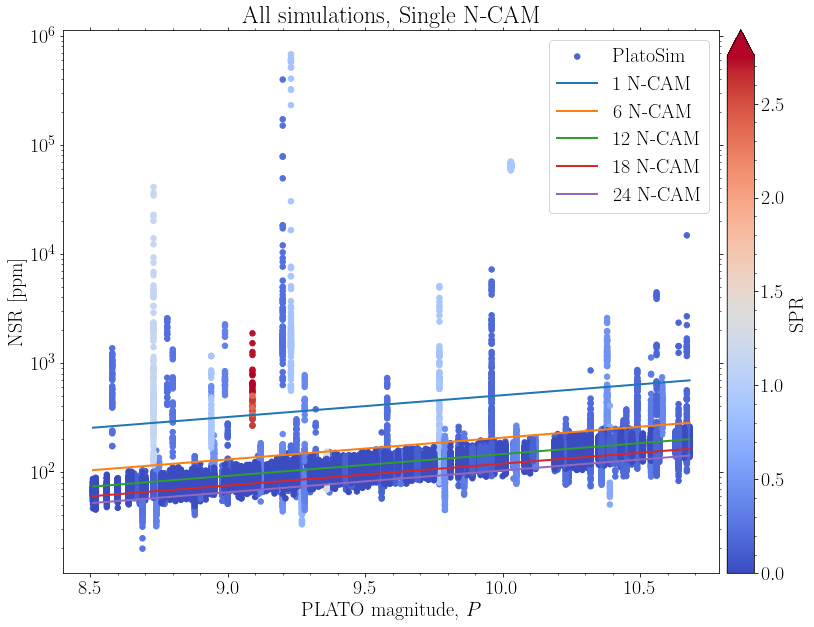

In [404]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, Ncam=12, column="SPR", cmap="coolwarm", figsize=(14,10))
ax.set_title("All simulations, Single N-CAM");

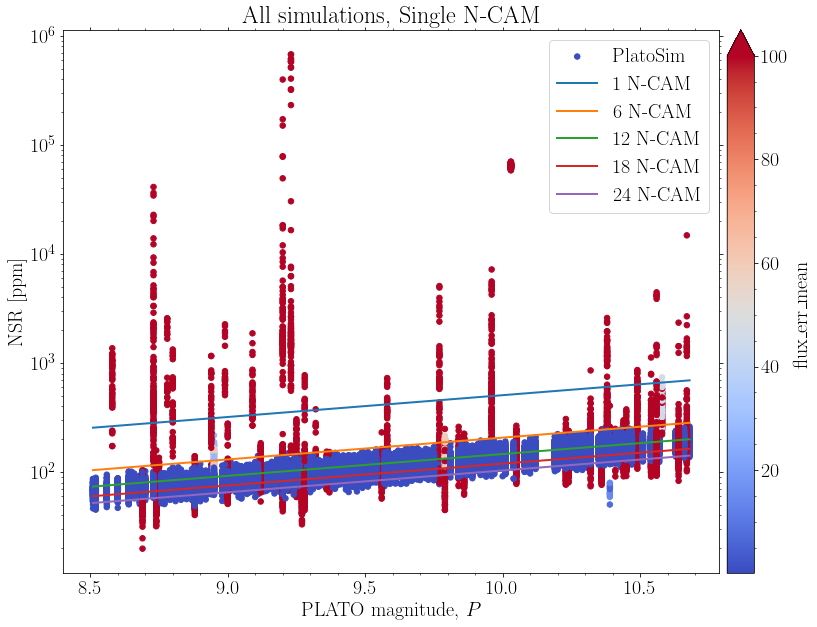

In [405]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, Ncam=12, column="flux_err_mean", cmap="coolwarm", figsize=(14,10))
ax.set_title("All simulations, Single N-CAM");

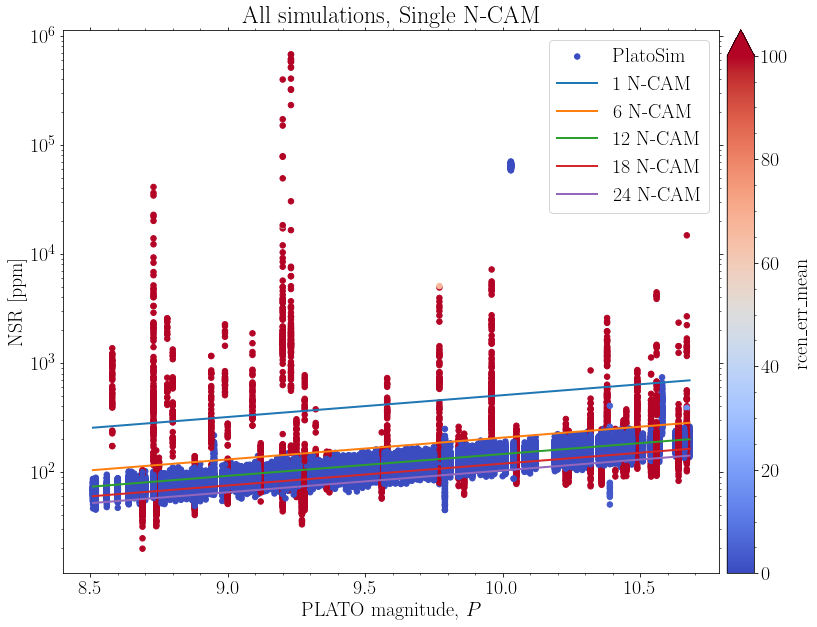

In [406]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, Ncam=12, column="rcen_err_mean", cmap="coolwarm", figsize=(14,10))
ax.set_title("All simulations, Single N-CAM");

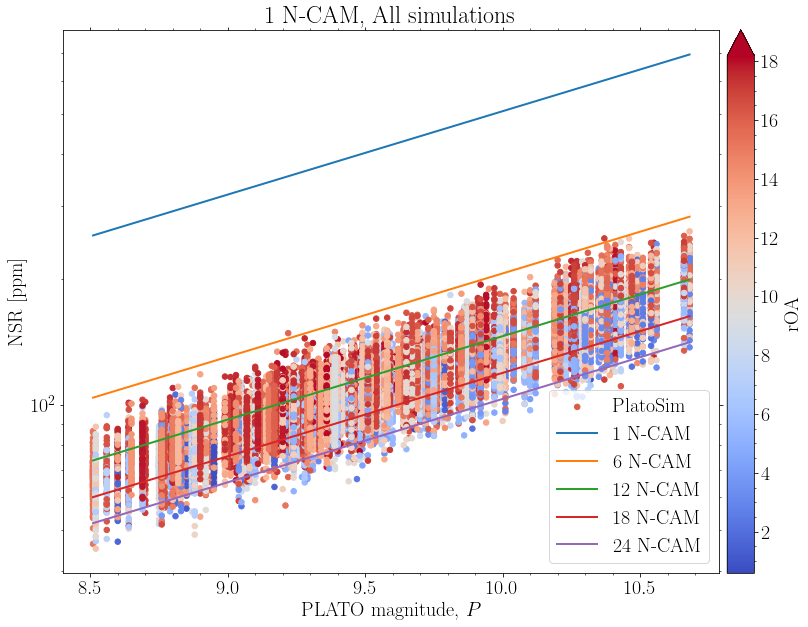

In [420]:
df1 = df.loc[df["SPR"] == 0]
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1, Ncam=12, column="rOA", cmap="coolwarm", figsize=(14,10))
ax.set_title("1 N-CAM, All simulations");

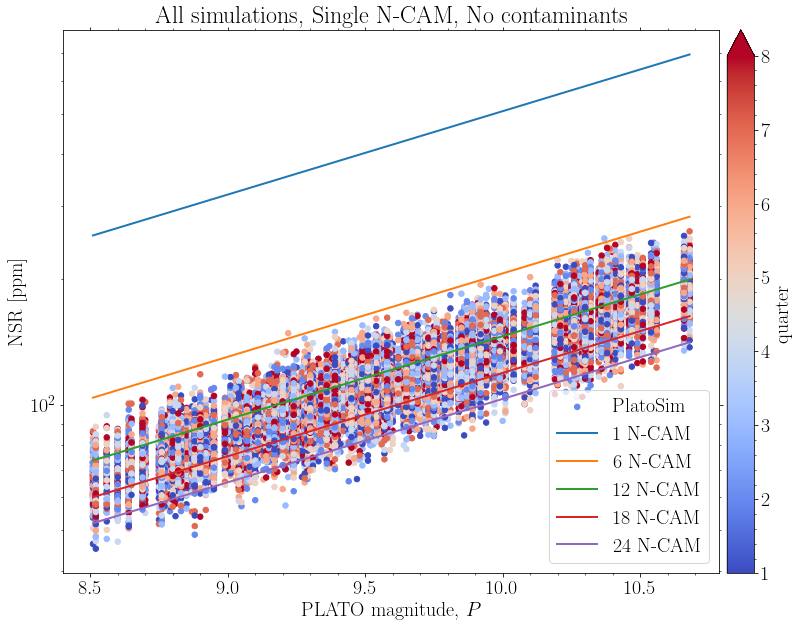

In [419]:
df1 = df.loc[df["SPR"] == 0]
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1, Ncam=12, column="quarter", cmap="coolwarm", figsize=(14,10))
ax.set_title("All simulations, Single N-CAM, No contaminants");

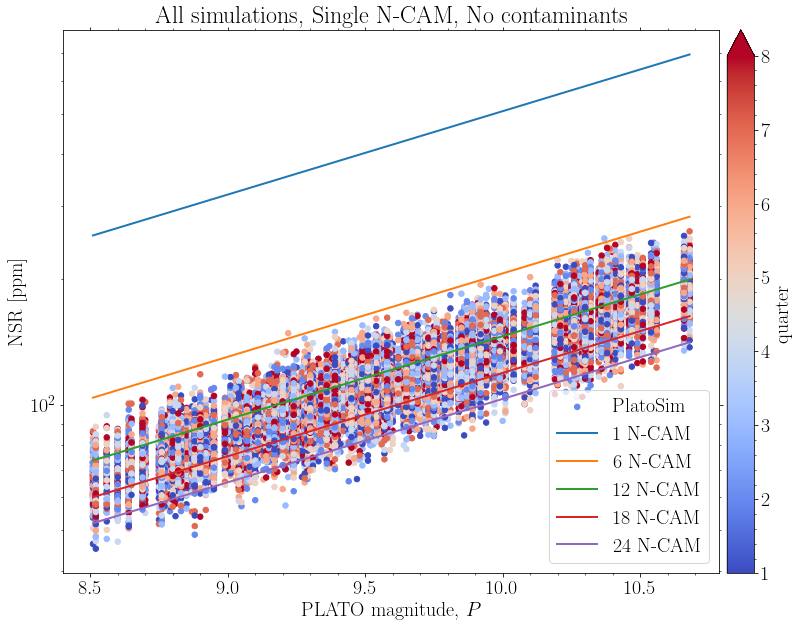

In [408]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df1, Ncam=12, column="quarter", cmap="coolwarm", figsize=(14,10))
ax.set_title("All simulations, Single N-CAM, No contaminants");

### 2.2.2) No Jitter: Only 1 quarter

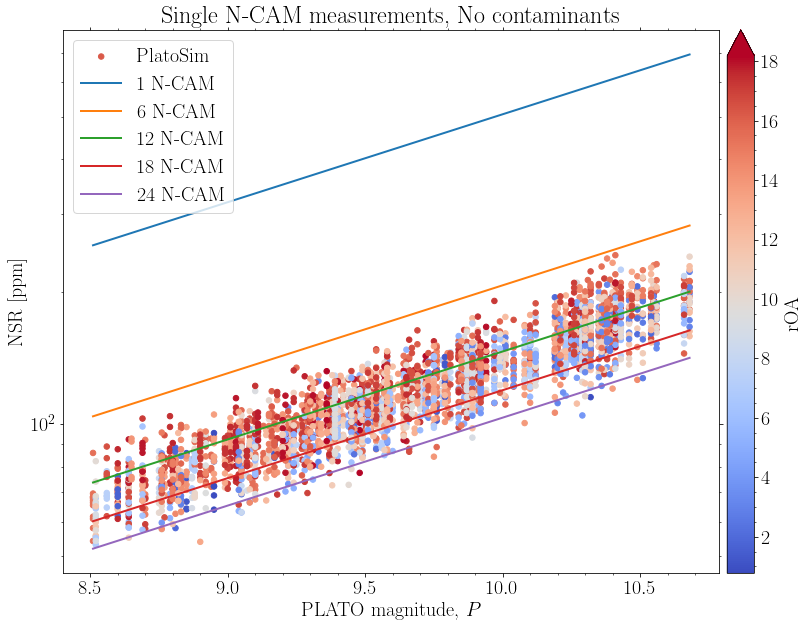

In [425]:
# Show only quarter
df2 = df1.loc[df1["quarter"] == 8]
fig, ax = pt.plotNSRvsMagnitude(df2, column="rOA", cmap="coolwarm", figsize=(14,10))
ax.set_title("Single N-CAM measurements, No contaminants");

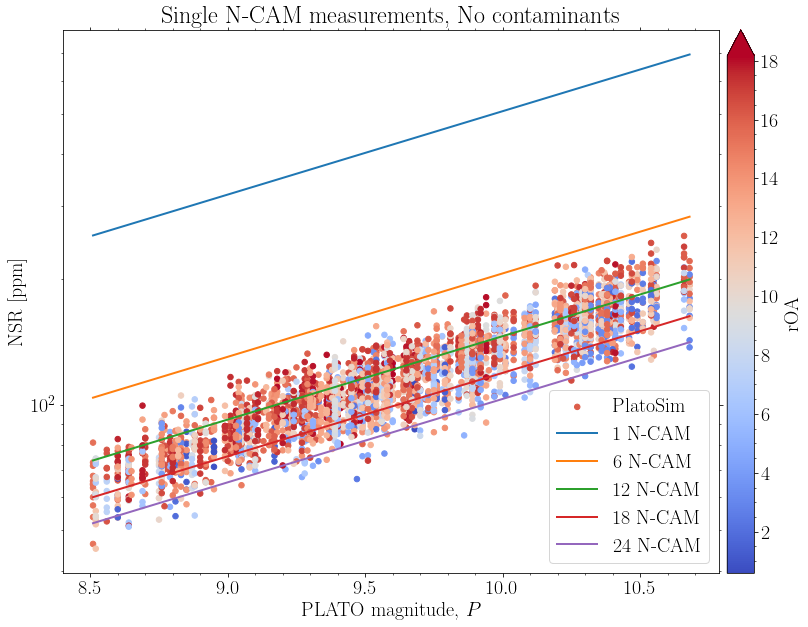

In [426]:
# Show only quarter
df2 = df1.loc[df1["quarter"] == 1]
fig, ax = pt.plotNSRvsMagnitude(df2, column="rOA", cmap="coolwarm", figsize=(14,10))
ax.set_title("Single N-CAM measurements, No contaminants");

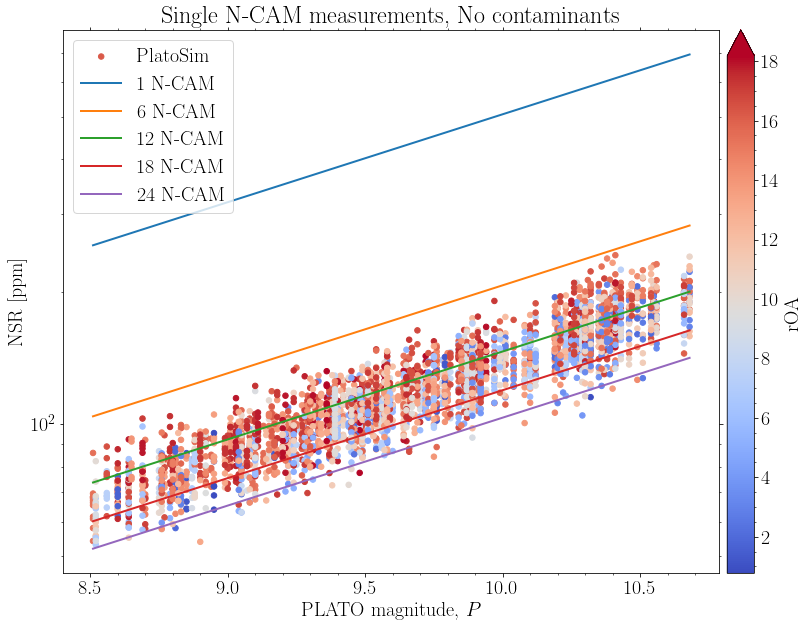

In [427]:
# Show only quarter
df3 = df1.loc[df1["quarter"] == 8]
fig, ax = pt.plotNSRvsMagnitude(df3, column="rOA", cmap="coolwarm", figsize=(14,10))
ax.set_title("Single N-CAM measurements, No contaminants");